In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

mumbai_df = pd.read_csv(
    "/mnt/c/ERA5_LSTM_Project/data/mumbai.txt",
    sep=r"\s+",
    skiprows=2,
    header=None,
    usecols=[0,1],
    names=["date","temperature"]
)

mumbai_df["temperature"] = pd.to_numeric(
    mumbai_df["temperature"],
    errors="coerce"
)

mumbai_df.head()

,date,temperature
0,2000-01-01,287.7911
1,2000-01-02,287.6064
2,2000-01-03,287.2173
3,2000-01-04,287.4983
4,2000-01-05,286.6647


In [ ]:
#kelvin to celcius
mumbai_df["temperature_c"] = (
    mumbai_df["temperature"] - 273.15
)

mumbai_df.head()

,date,temperature,temperature_c
0,2000-01-01,287.7911,14.6411
1,2000-01-02,287.6064,14.4564
2,2000-01-03,287.2173,14.0673
3,2000-01-04,287.4983,14.3483
4,2000-01-05,286.6647,13.5147


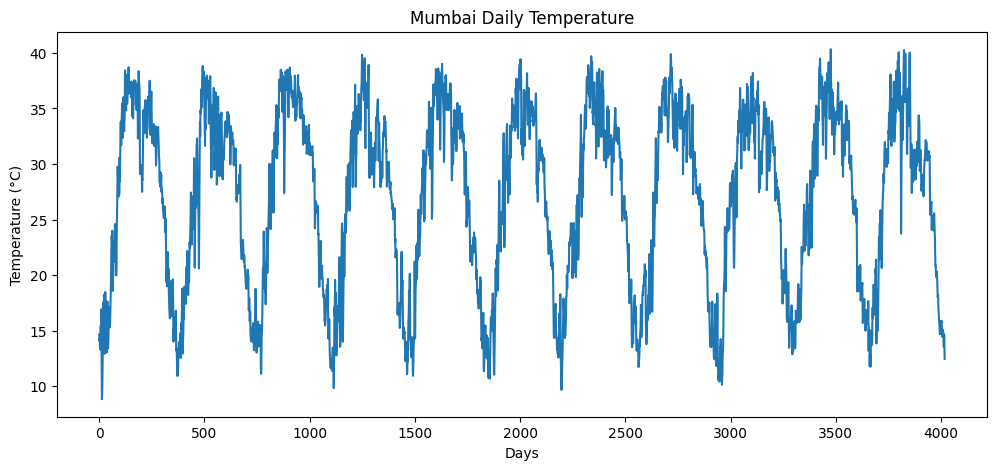

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    mumbai_df["temperature_c"]
)

plt.title("Mumbai Daily Temperature")

plt.xlabel("Days")

plt.ylabel("Temperature (°C)")

plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    mumbai_df[["temperature_c"]]
)

In [ ]:
sequence_length =30 
X = []
y = []

for i in range(
    sequence_length,
    len(scaled_data)
):

    X.append(
        scaled_data[
            i-sequence_length:i
        ]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)
y = np.array(y)

In [ ]:
X = np.reshape(
    X,
    (X.shape[0], X.shape[1], 1)
)

In [ ]:
print(X.shape)
print(y.shape)

(3988, 30, 1)
(3988, 1)


In [ ]:
#train test split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)

print(X_test.shape)

(3190, 30, 1)
(798, 30, 1)


In [ ]:
#building LSTM Model
from keras.models import Sequential

from keras.layers import (
    LSTM,
    Dense,
    Input
)

model = Sequential()

model.add(Input(shape=(X_train.shape[1], 1)))

model.add(LSTM(
    units=100,
    return_sequences=False
))

model.add(Dense(1))

In [ ]:
model.compile(
    optimizer='adam',     #how weights should be updated 
    loss='mean_squared_error'   # how prediction error is measured
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0166 - val_loss: 0.0047
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0046 - val_loss: 0.0047
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0044 - val_loss: 0.0041
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0041 - val_loss: 0.0037
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0032 - val_loss: 0.0028
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 

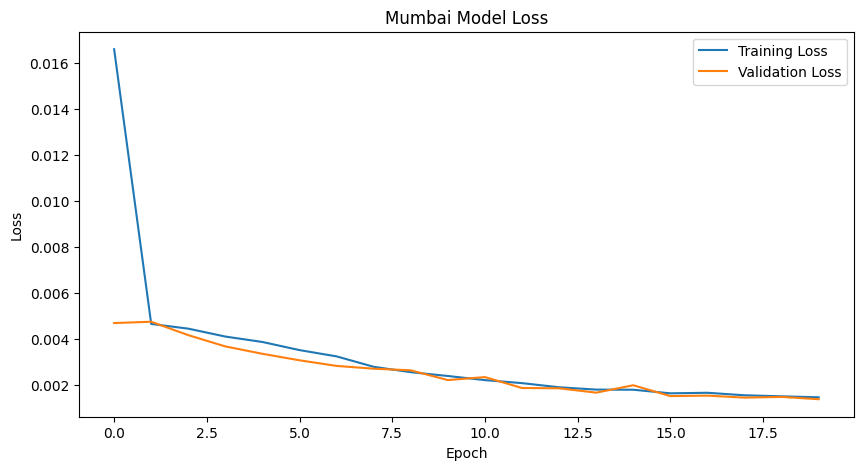

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Mumbai Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
#Predictions
predictions = model.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
#  inverse scaling 
predictions = scaler.inverse_transform(   #gives 2d output converst normalised to celsius
    predictions.reshape(-1,1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

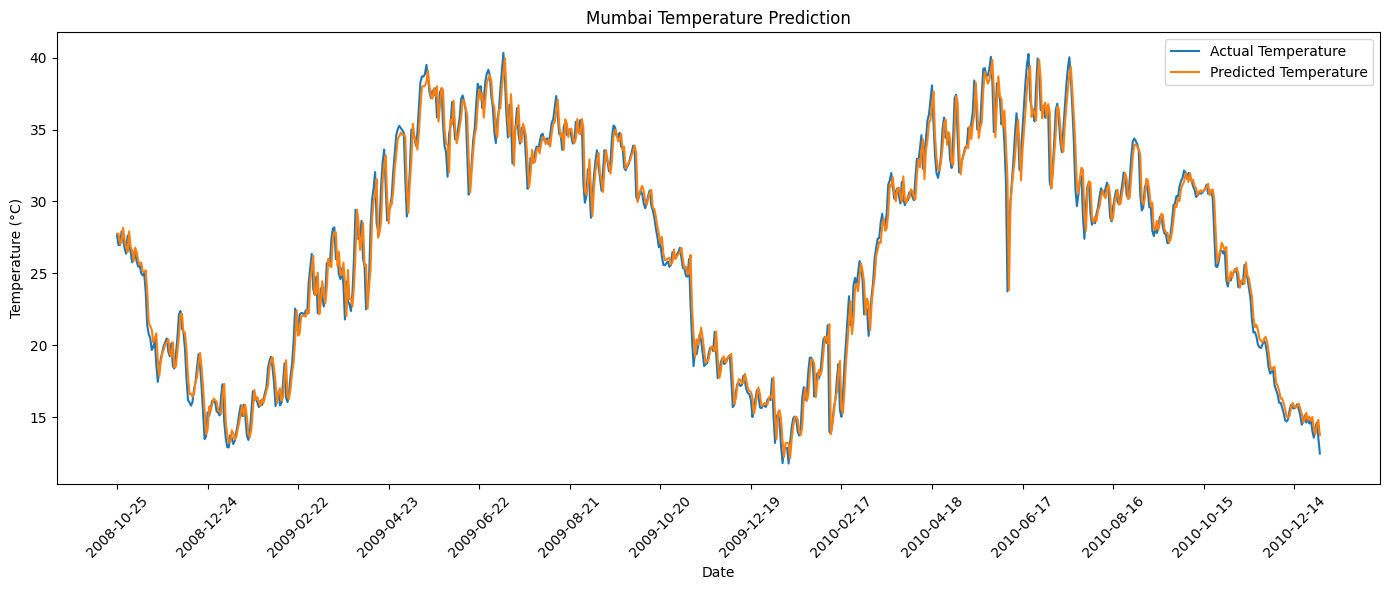

In [ ]:
#Forecast Plot 
test_dates = mumbai_df['date'][
    -len(y_test_actual):
]

plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    y_test_actual,
    label='Actual Temperature'
)

plt.plot(
    test_dates,
    predictions,
    label='Predicted Temperature'
)

plt.title('Mumbai Temperature Prediction')

plt.xlabel('Date')

plt.ylabel('Temperature (°C)')

plt.xticks(
    test_dates[::60],
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

mae = mean_absolute_error(
    y_test_actual,
    predictions
)

r2 = r2_score(
    y_test_actual,
    predictions
)

correlation = np.corrcoef(
    y_test_actual.flatten(),
    predictions.flatten()
)[0,1]

covariance = np.cov(
    y_test_actual.flatten(),
    predictions.flatten()
)[0,1]

print("RMSE:", rmse)

print("MAE:", mae)

print("R²:", r2)

print("Correlation:", correlation)

print("Covariance:", covariance)

RMSE: 1.1625560001071293
MAE: 0.8463725651714722
R²: 0.9772817295775036
Correlation: 0.9886500976582332
Covariance: 57.88544763692816


In [ ]:
results_mumbai = pd.DataFrame({
    "City": ["Mumbai"],
    "RMSE": [rmse],
    "MAE": [mae]
})

results_mumbai.to_csv(
    "../outputs/mumbai_metrics.csv",
    index=False
)

In [ ]:
model.save("mumbai_lstm.keras")